In [10]:
# load a matrix from a space-separated file and show it as an image
import sys
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/')
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import os
from stat_utils import bic_gaussian_from_rmse
from model_utils import force_model_params, migrate_output_scale_to_input_scale_state_dict
from part2fig_utils import compute_k_params, eval_single_wrap, myplot,  eval_paradigm_with_inoutmaps

from models_part2 import BatchedElboGenerativeModelTopMulti
import yaml
from types import SimpleNamespace

import pickle
# default seed count
seeds = 128//2 # 128*2#*2 # 18#72#18 #128
#

#Big REF1
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/state_space_2ratesBound/'; seeds = 128*2

#!!!
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/xlpfSftPlusV2WdepLRscaleOutClmpLRRecvov40m_inj0p4_with_seeds_1'
result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/froBmedian_MEANWZeroORDERxlpfSftPlusWdepLRscaleOutClmpLRRecvov40m_inj0p4_with_Nseeds_1'; at_y_eq_inf = 'skip_plasticity'



In [2]:

#load the best model state dict
best_model_dir = os.path.join(result_path, 'best_model_state_dict')
model_state_dict_save_path = os.path.join(best_model_dir, 'model_state_dict.pt')
best_model_state_dict = torch.load(model_state_dict_save_path, map_location=torch.device('cpu'))

args_save_path = os.path.join(best_model_dir, 'args.yaml')
with open(args_save_path) as f:
    args = yaml.load(f, Loader=yaml.FullLoader)

In [3]:
rcConf = {
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
}
# ufigx,ufigy = (8.5 / 2, 4.2 / 1.5)
ufigx,ufigy = (7.5 / 2, 4.2 / 1.5)

In [4]:
args = SimpleNamespace(**args)


In [5]:
args

namespace(apply_lr_decay=True,
          apply_scaled_soft_plus_on_w_in_params=False,
          assume_opt_output_noise=True,
          at_y_eq_inf='skip_plasticity',
          batch_param_period=64,
          batch_param_tie_grad='sum',
          batch_param_tie_names='all',
          bound_weight_decay=False,
          bs=16,
          channel_trial_extra_error=0.0,
          debug_flag_win2nd_column_positive_only=False,
          develop_b_tgt=0.0,
          direct_inj_limiter=1.0,
          disable_lpfs=True,
          enable_bias_update=False,
          enable_direct_injection=False,
          enable_elpf=False,
          enable_input_scale_tuning=False,
          enable_output_scale_tuning=True,
          enable_q_scale_tuning=False,
          enable_qlpf=False,
          enable_separate_win_per_rate=False,
          enable_sigma_b_tuning=False,
          enable_u_feedback_scale_tuning=False,
          enable_w_in_plasticity=False,
          enable_w_in_scale_tuning=False,
      

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [7]:
# if args.enable_output_scale_tuning:
#     if hasattr(args, 'enable_input_scale_tuning') and args.enable_input_scale_tuning:
#         raise ValueError('Both output scale tuning and input scale tuning cannot be enabled at the same time, for now.')
#     if args.nl_activation != 'relu':
#         raise ValueError('Scaling migration is currently only implemented for ReLU nonlinearity'
#         '.')
#     args.enable_output_scale_tuning = False
#     args.enable_input_scale_tuning = True
#     # args.softclamp_input_scale_0to1 = args.softclamp_output_scale_0to1 if hasattr(args, 'softclamp_output_scale_0to1') else False

#     best_model_state_dict = migrate_output_scale_to_input_scale_state_dict(best_model_state_dict, 
#                                                                            remove_output_scale=True,
#                                                                            apply_softclamp_output_scale_0to1=args.softclamp_output_scale_0to1 if hasattr(args, 'softclamp_output_scale_0to1') else False,
#                                                                            model_for_softclamp=BatchedElboGenerativeModelTopMulti(device=device, args=args) ) 
#     print('Migrated output scale parameters to input scale parameters in the model state dict, and disabled output scale tuning while enabling input scale tuning.')
#     args.softclamp_output_scale_0to1 = False

# args.fixed_injection_param = 0.4



In [8]:
model = BatchedElboGenerativeModelTopMulti(device=device, args=args, 
                                           **(dict(fudge=args.fudge) if hasattr(args, 'fudge') else {}  )).to(device)
model.get_biases_and_w_in(args.n, device=device)
model.load_state_dict(best_model_state_dict)

<All keys matched successfully>

In [11]:
paradigm_file='/homes/ar2342/one_more_dir/contextual_frogs/signoffrepertoire4.3.pkl'

with open(paradigm_file, "rb") as f:
        playlist = pickle.load(f)

In [18]:
my_probe_values = np.arange(-1.5, 1.5 + 0.05 / 2, 0.025, dtype=np.float32)
stopping_point = 150
herz_run_num = 1
recorded_paradigms = [f'herzfeld,z=0.1${herz_run_num}',f'herzfeld,z=0.5${herz_run_num}',f'herzfeld,z=0.9${herz_run_num}']
records = {}
for paradigm in recorded_paradigms:
    records[paradigm] = eval_paradigm_with_inoutmaps(model, args, np.float32(playlist[paradigm][:stopping_point]), my_probe_values)

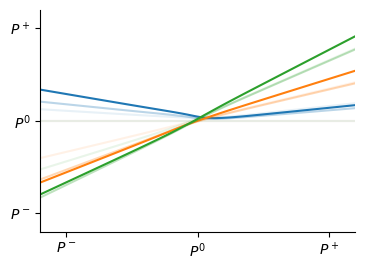

In [19]:
plt.rcParams.update(rcConf)


fig1, ax_map = plt.subplots(figsize=(ufigx, ufigy))
style = '-'

requested_timepoints = [0, 46, 46+45, 46+45*2]
# requested_timepoints += [t+10 for t in requested_timepoints]
colours =  ['tab:blue', 'tab:orange','tab:green']
alphas = [0.05, 0.1, 0.3, 1]
# styles = [,]
for paradigm, colour in zip(recorded_paradigms, colours):
    for t, alpha in zip(requested_timepoints, alphas):
        # mean_inout = 1./16*records[paradigm]['inoutmaps'][t].T @ best_model_state_dict['input_scale'].numpy()
        plt.plot(my_probe_values,records[paradigm]['inoutmaps'][t].mean(axis=0), color=colour, linestyle=style, alpha=alpha)
        # ax_map.plot(my_probe_values,mean_inout, color=colour, linestyle=style, alpha=alpha)
# plt.plot(my_probe_values,my_probe_values, color='black', linestyle=':')

ax_map.set_xticks([-1, 0, 1])
ax_map.set_xticklabels([ '$P^-$', '$P^0$', '$P^+$'])

ax_map.set_yticks([-1, 0, 1])
ax_map.set_yticklabels([ '$P^-$', '$P^0$', '$P^+$'])

# ax_map.set_xlimit([-1, 0, 1])
ax_map.set_ylim([-1.2, 1.2]) 
ax_map.set_xlim([-1.2, 1.2]) 
fig1.tight_layout()
# fig1.savefig('part2_herzf_inoutmaps.svg', format='svg', bbox_inches='tight')

NameError: name 'savings' is not defined

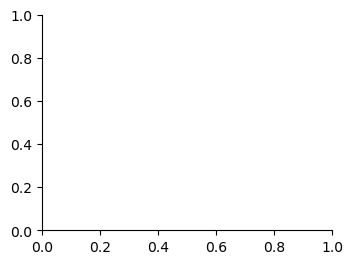

In [ ]:



plt.rcParams.update(rcConf)

fig1, ax_traj = plt.subplots(figsize=(ufigx, ufigy))

myplot(savings[:220],align_by_endpoint=False)
myplot(savings[220:],align_by_endpoint=False)

ax_traj.set_xticks(requested_timepoints[:3])
# ax_traj.set_xticklabels([ '$P^+$\n onset', '$P^-$\n onset', '$P^c$\n onset'])
ax_traj.set_xticklabels([ '$P^+$', '$P^-$', '$P^c$'])
ax_traj.set_xlabel('trials')


ax_traj.set_yticks([-1, 0, 1])
ax_traj.set_ylabel('adaptation')

# ax_traj.set_yticklabels([ '$P^+$', '$P^0$', '$P^+$'])